# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [104]:
R = 2.
H = 1.

NGSOLVE = True

lc = 1.

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [105]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

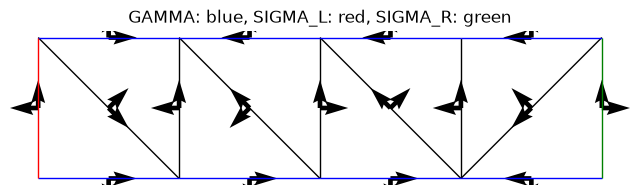

In [106]:
waveguide.plot()

In [107]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [108]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [109]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.RIGHT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [110]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [111]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [112]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, NtD_modes=NtD_modes, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [113]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 15
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

120

and an assembler:

In [114]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [115]:
from trefftz.problem import Problem
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)  #, numerics=numerics)

In [116]:
A = P.assemble_LHS()

Interior: 100%|██████████| 7/7 [00:00<00:00, 18.83edge/s]


assembling local operators
region: Gamma


100%|██████████| 8/8 [00:00<00:00, 152.99edge/s]


region: Sigma_L


100%|██████████| 1/1 [00:00<00:00, 153.56edge/s]


region: Sigma_R


100%|██████████| 1/1 [00:00<00:00, 168.05edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 1/1 [00:00<00:00,  1.77edge/s]


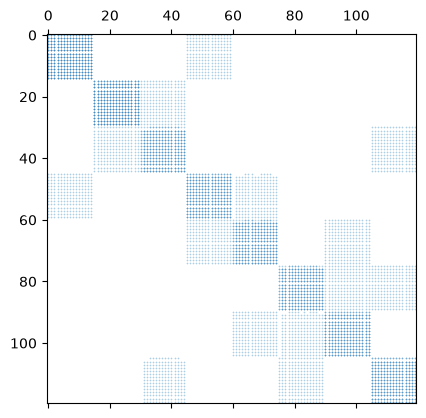

In [117]:
import matplotlib.pyplot as plt 
plt.spy(A, markersize=0.1)

In [118]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [119]:
b = P.assemble_RHS()

region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(2.676524082942567e-16+1.4142671243033168e-15j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-0.430740325101806-7.72992320886233j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(10.927321048669196-7.468526728885282j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(5.287276724455388-6.798960331581336j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(0.3774402256755147-2.438486162709828j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-1.9437081630392492+2.7043275595162486j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-0.39398636495798567-5.913554862146638j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(-1.2909150006110741-0.4244669861751031j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=np.complex128(0.5418882953974005-1.2461905297612186j)
region=<BoundaryRegions.SIGMA_L: 'Sigma_L'>, value=

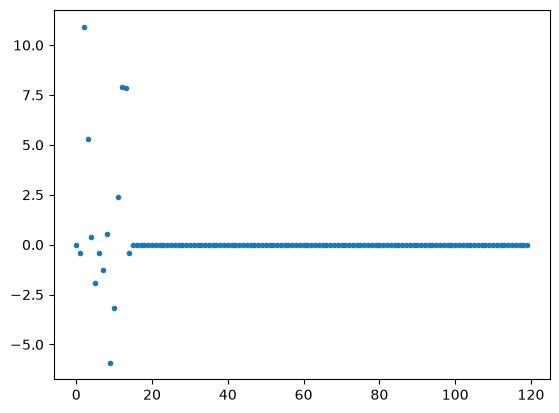

In [120]:
plt.plot(b.real,'.')

In [121]:
import numpy as np
np.count_nonzero(b)/N_theta

np.float64(1.0)

In [122]:
P.solve()

In [123]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 5.93945823e-03+7.94112036e-02j, -3.70145446e-02+8.44476507e-02j,
         3.47405580e-01+3.51726771e-01j, -1.08632710e-02+7.89533528e-02j,
         2.08775037e-02-2.45801450e-02j, -2.22716790e-02+2.55694762e-03j,
        -1.61569913e-02+2.06499588e-02j, -1.14338760e-02-2.10247178e-02j,
        -1.54787796e-02+9.30559292e-03j, -1.49024728e-02-8.75131422e-05j,
         6.98253204e-03-1.71277658e-02j,  1.12035961e-02+2.98955987e-02j,
        -8.25486846e-02+3.94771854e-03j,  4.42937537e-01+2.05856106e-01j,
         3.92754950e-02-8.53474860e-02j],
       [-3.42031860e-02-5.00341430e-02j,  7.39472504e-02+4.72486517e-02j,
         4.37243169e-01-2.42959687e-01j, -7.08892280e-02-1.27314980e-02j,
         8.58853918e-03-3.00829224e-02j,  1.69276528e-02+1.70035800e-02j,
        -1.72506763e-02+1.57197947e-02j, -2.81193315e-02+1.47162486e-02j,
         2.94459379e-02+3.60139842e-02j, -6.17588698e-02+1.50610697e-02j,
        -6.54288133e-02+3.50357852e-02j,  4.92105112e-02+6.26956985e-0

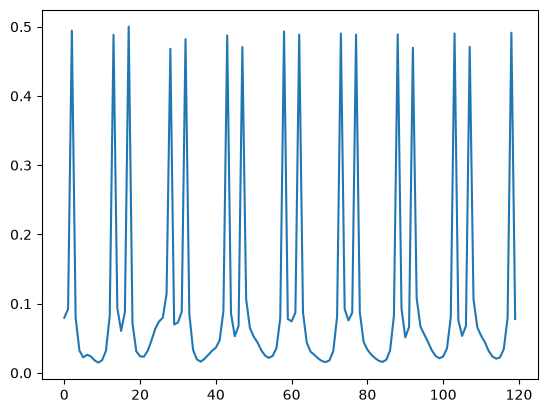

In [124]:
plt.plot(np.abs(P.u_h.coefficients))

In [125]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

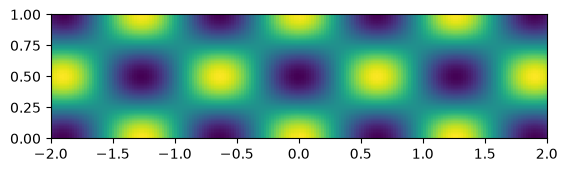

In [126]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

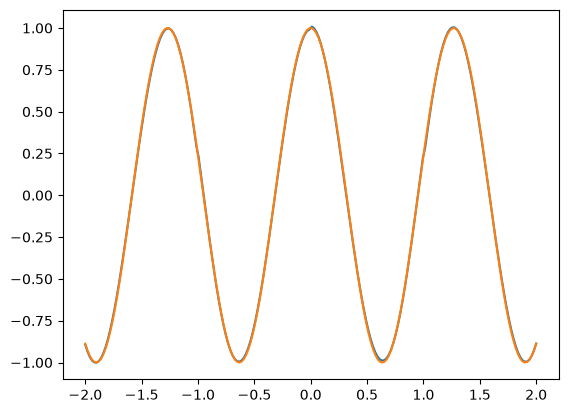

In [127]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)

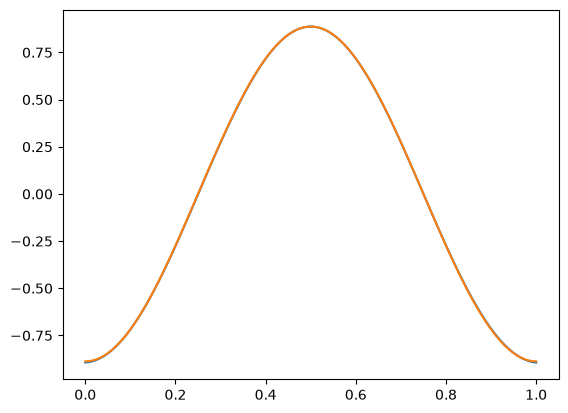

In [128]:
plt.plot(y,Z[:,0].real)
plt.plot(y,np.exp(-1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*R).real*np.cos(t*np.pi/H*y))